# Chemical space

This tutorial is about the one design decision that most distinguishes matverse
from a DataFrame with a `structure` column: **`X` is the composition matrix and
`var` is the periodic table**.

It picks up where [Screening, end to end](screening.ipynb) left off — same
Al–Ni–Cu library, same `passes` column — and asks the question that follows
every screen: *what chemistry is on the shortlist?*

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...
🧪 Calculators available: 6
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — mace-mpa (unstated)
    • mace-omat — mace-omat (unstated)
    • sevennet — sevennet (unstated)
    • chgnet — chgnet (unstated)


🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 213   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

Rebuilding the screening object in one cell: three elemental fcc metals at their
published lattice parameters, four hypothetical intermetallics, relaxed and
screened with `emt`.

In [2]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    return Structure(Lattice.cubic(a), [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


elemental = mv.datasets.metals(["Al", "Cu", "Ni"])
md = mv.data.from_structures(mv.structures(elemental) + [
    l12("Al", "Cu", 3.90), l12("Cu", "Al", 3.70), l12("Al", "Ni", 3.78),
    Structure(Lattice.cubic(2.89), ["Al", "Ni"], [[0, 0, 0], [.5, .5, .5]]),
])

mv.pp.describe(md)
mv.calc.relax(md, level="emt", fmax=0.05)
mv.thermo.hull(md, level="emt", source="relaxed_emt")
mv.screen.filter(md, e_above_hull_emt__lt=0.12, density__lt=8.0)

md.obs[["formula", "e_above_hull_emt", "density", "passes"]].round(3)

,formula,e_above_hull_emt,density,passes
0,Al,0.000,2.699,True
1,Cu,0.000,8.935,False
2,Ni,0.000,8.908,False
3,Al3Cu,0.083,4.045,True
4,AlCu3,0.115,7.134,True
5,Al3Ni,0.162,4.293,False
6,AlNi,0.348,5.894,False


## Why elements are the right axis

A composition matrix is materials × elements — sparse, non-negative, and almost
entirely zero, because nearly every material draws on five or fewer of 118
columns. That is structurally a cells × genes matrix.

In [3]:
pd.DataFrame(md.X.toarray(), index=md.obs["formula"], columns=md.var_names)

element,Al,Ni,Cu
formula,,,
Al,1.0,0.0,0.0
Cu,0.0,0.0,1.0
Ni,0.0,1.0,0.0
Al3Cu,3.0,0.0,1.0
AlCu3,1.0,0.0,3.0
Al3Ni,3.0,1.0,0.0
AlNi,1.0,1.0,0.0


Counts come from the **reduced** formula, so a supercell and its primitive cell
occupy the same point in chemical space. Cell size belongs in `obs['nsites']`,
not in the chemistry.

`var` carries the periodic table, which is what makes element-level results
interpretable without a lookup somewhere else:

In [4]:
md.var[["Z", "electronegativity", "period", "is_transition_metal"]]

,Z,electronegativity,period,is_transition_metal
element,,,,
Al,13.0,1.61,3.0,False
Ni,28.0,1.91,4.0,True
Cu,29.0,1.90,4.0,True


```{note}
Economic properties — price, supply risk, criticality — are deliberately **not**
shipped. They are jurisdiction- and date-dependent and no authoritative open
table exists, so inventing numbers would make `mv.screen.filter(md,
supply_risk__lt=0.3)` return confident nonsense. Attach your own instead.
```

In [5]:
mv.elements.annotate(md, pd.DataFrame(
    {"price_usd_kg": [2.4, 18.0, 9.5]}, index=["Al", "Ni", "Cu"]))

md.var[["price_usd_kg"]]

,price_usd_kg
element,
Al,2.4
Ni,18.0
Cu,9.5


## The dividend inside the library

Because `X` holds the composition and `var` holds the element properties, the
classic composition descriptor — the weighted mean, spread and range of element
properties across a formula — is a matrix product of two things the object is
already carrying.

In [6]:
mv.feat.element_stats(md)
md.obsm["X_element_stats"].shape

(7, 130)

Check one by hand. For Al₃Cu the weighted mean electronegativity should be
exactly `0.75 × 1.61 + 0.25 × 1.90`:

In [7]:
names = list(md.uns["features"]["X_element_stats"]["names"])
j = names.index("electronegativity_mean")
row = list(md.obs["formula"]).index("Al3Cu")

md.obsm["X_element_stats"][row, j], 0.75 * 1.61 + 0.25 * 1.90

(np.float64(1.6825), 1.6825)

Those descriptors are also a distance, which makes the library a matrix you can
look at.

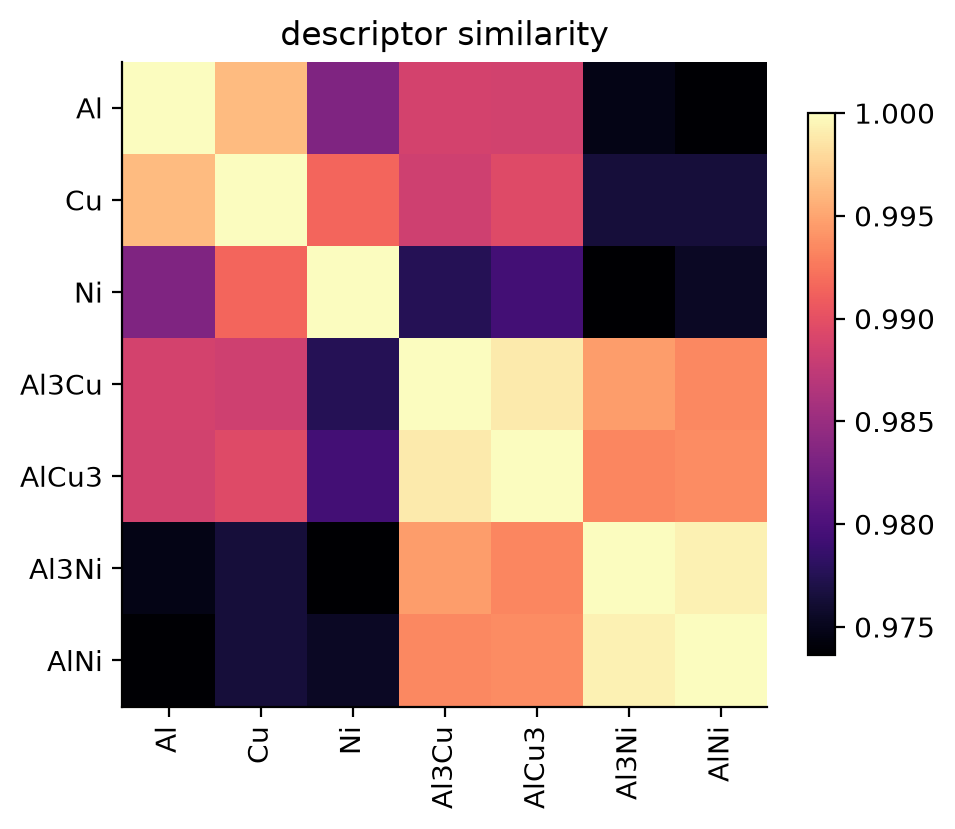

In [8]:
import matplotlib.pyplot as plt

mv.feat.similarity(md)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(md.obsp["similarity_X_element_stats"], cmap="magma")
labels = list(md.obs["formula"])
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)
ax.set_title("descriptor similarity")
fig.colorbar(im, ax=ax, shrink=0.8)

The two Al–Cu orderings sit next to each other and the elementals separate,
which is the expected structure and therefore worth checking — a similarity
matrix with no block structure means the descriptor is not carrying chemistry.

`min`, `max` and `range` are taken over the elements that are *present at all*,
so "the most electronegative element in this compound" is the quantity it sounds
like rather than an amount-weighted blend.

Composition descriptors cannot tell two polymorphs apart, because polymorphs have
the same composition. When that matters, reach for a structure descriptor:

In [9]:
try:
    mv.feat.soap(md)
    result = md.obsm["soap"].shape
except ImportError as exc:
    result = str(exc)[:170]     # needs matverse[descriptors]
result

'mv.feat.soap needs dscribe (`pip install matverse[descriptors]`). mv.feat.element_stats is the dependency-free alternative, but it cannot separate polymorphs.'

A site-averaged SOAP vector per structure, which separates two polymorphs of
one composition where a composition descriptor cannot.

```{note}
Needs **dscribe**, which imports `sparse`, which imports `numba`, which pins
numpy below 2.5. On a newer numpy the install resolves and the import does not,
so this cell reports rather than fails.
```

### Descriptors matverse does not ship

`mv.feat.register_embedder` is the door for anything that turns a structure into
a vector — a pretrained graph network, a fingerprint from another library, a
scheme of your own. `mv.feat.embed` runs it and records where the numbers came
from.

In [10]:
def mass_and_volume(structures):
    """A deliberately trivial embedder.

    It takes the whole list and returns one row per structure — the batch
    contract, so a model that runs on a GPU is called once rather than n times.
    """
    return np.array([[s.composition.weight / len(s), s.volume / len(s)]
                     for s in structures])


mv.feat.register_embedder("toy", mass_and_volume, method="mass and volume",
                          license="n/a")
mv.feat.embed(md, model="toy")

pd.DataFrame(md.obsm["X_toy"], index=md.obs["formula"],
             columns=["mean mass", "volume per atom"]).round(3)

,mean mass,volume per atom
formula,,
Al,26.982,16.601
Cu,63.546,11.809
Ni,58.693,10.941
Al3Cu,36.123,14.830
AlCu3,54.405,12.663
Al3Ni,34.910,13.503
AlNi,42.837,12.069


In [11]:
md.uns["features"]["X_toy"]

{'names': ['toy_0', 'toy_1'],
 'featurizer': 'mass and volume',
 'license': 'n/a'}

Which model produced the block, and under what licence, is recorded next to it
in `uns['features']` — the same slot `mv.feat.element_stats` writes to. Two
descriptor blocks from different models are therefore distinguishable after the
fact, which matters the moment two people in a group use different checkpoints
of the same network.

```{note}
Note that this is `uns['features']`, not `uns['levels']`. A descriptor is not a
level of theory: it makes no claim about energy and cannot be mixed into a hull,
so it does not need the machinery that stops that happening. The rule is that
the record goes where the thing being described lives.
```

## Mapping the space

In [12]:
mv.pp.normalize_composition(md)     # -> layers['fraction']
mv.tl.pca(md, n_comps=2)
mv.tl.neighbors(md, n_neighbors=3)
mv.tl.cluster(md, method="kmeans", n_clusters=2)

md.obs[["formula", "cluster"]]

,formula,cluster
0,Al,0
1,Cu,1
2,Ni,0
3,Al3Cu,0
4,AlCu3,1
5,Al3Ni,0
6,AlNi,0


`normalize_composition` writes atomic fractions to a **layer** rather than
replacing `X`, because a hull needs the counts and a chemical-space map needs
the fractions. `mv.tl.pca` defaults to the fraction layer when it exists: raw
counts scale with the size of the formula unit, so `Fe2O3` and `Fe4O6` would
otherwise sit at different points despite being the same chemistry.

PCA here is an exact SVD. The element axis is at most 118 columns wide, so there
is nothing to approximate and no randomised solver to configure.

Text(0.5, 1.0, 'chemical space, coloured by cluster')

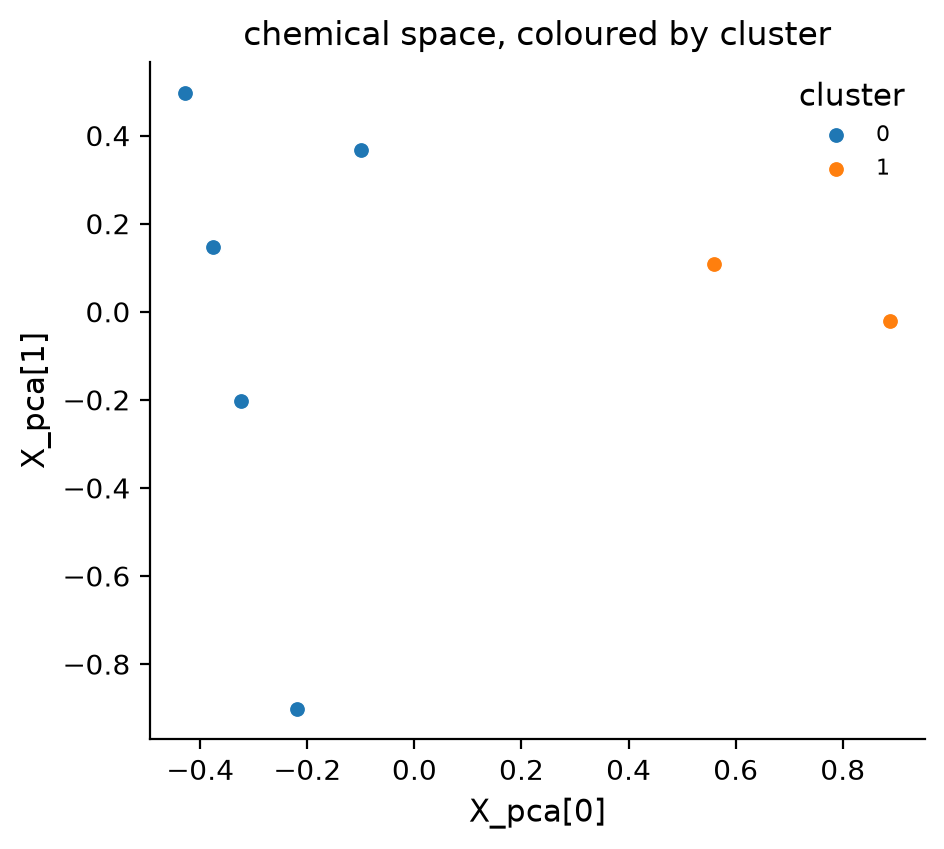

In [13]:
ax = mv.pl.embedding(md, color="cluster")
ax.set_title("chemical space, coloured by cluster")

## The question that follows every screen

You have a shortlist. What chemistry is on it?

In [14]:
mv.tl.rank_elements_groups(md, "passes")

md.uns["rank_elements_groups"]["True"]

,element,n_in_group,n_rest,frac_in_group,frac_rest,odds_ratio,pval,qval,log2_odds,group
0,Ni,0,3,0.000000,0.75,0.0,0.142857,0.428571,NaN,True
1,Al,3,2,1.000000,0.50,inf,0.428571,0.485714,inf,True
2,Cu,2,1,0.666667,0.25,6.0,0.485714,0.485714,2.584963,True


This is `rank_genes_groups` with the nouns changed, and it is the operation that
justifies the whole design choice. Answering the same question from a DataFrame
of averaged Magpie descriptors means writing the contingency table and the test
by hand, every time, for every screen.

Two routes, because "which elements" has two meanings — how *often* an element
appears in the group, and how *much* of it there is.

In [15]:
mv.tl.rank_elements_groups(md, "passes", method="fraction")   # Wilcoxon

md.uns["rank_elements_groups"]["True"][
    ["element", "mean_frac_in_group", "mean_frac_rest", "diff", "pval", "qval"]]

,element,mean_frac_in_group,mean_frac_rest,diff,pval,qval
0,Ni,0.000000,0.4375,-0.437500,0.111612,0.323887
1,Al,0.666667,0.3125,0.354167,0.215925,0.323887
2,Cu,0.333333,0.2500,0.083333,0.595883,0.595883


Both report an uncorrected p-value and a Benjamini–Hochberg q-value. With seven
materials nothing here is significant, and the table says so — which is the point
of reporting both.

The natural display is the periodic table, in the way a dot plot is the natural
display for differential expression.

Text(0.5, 1.0, 'elements enriched on the shortlist')

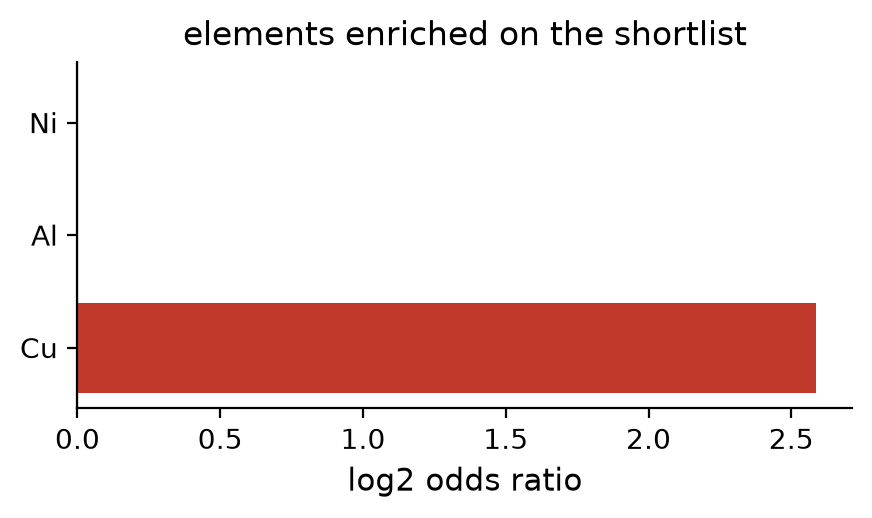

In [16]:
mv.tl.rank_elements_groups(md, "passes")
ax = mv.pl.rank_elements_groups(md, group="True")
ax.set_title("elements enriched on the shortlist")

The bar chart when you want the numbers; the periodic table when you want the
layout.

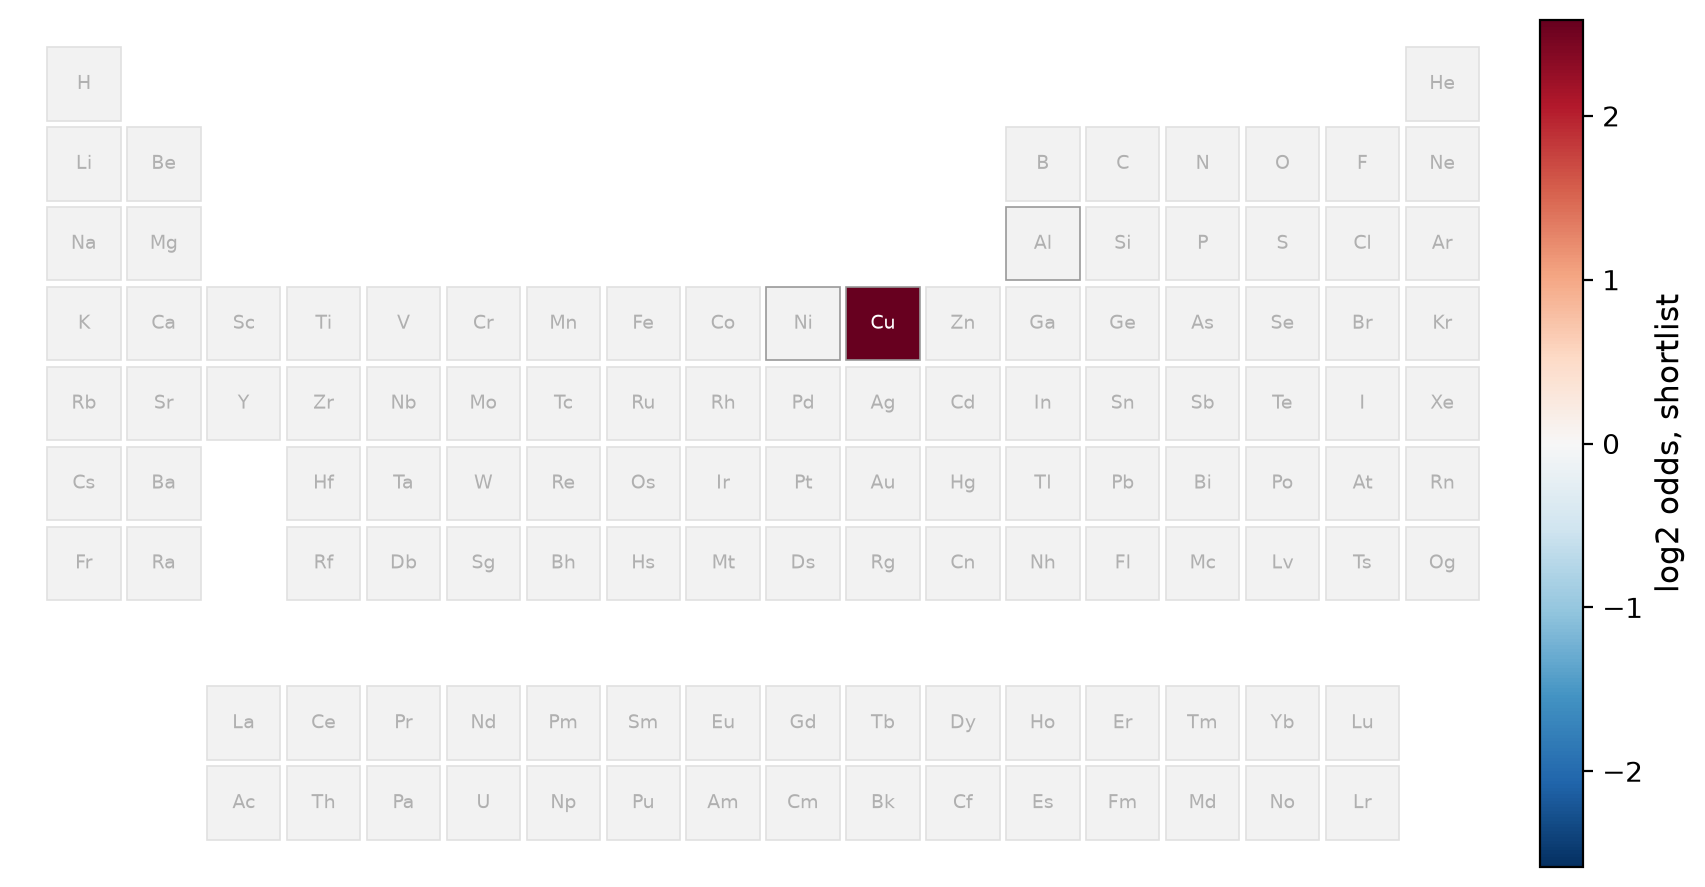

In [17]:
frame = md.uns["rank_elements_groups"]["True"]
scores = frame.set_index("element")["log2_odds"].reindex(md.var_names)

ax = mv.pl.periodic_table(md, values=scores.to_numpy(),
                          label="log2 odds, shortlist", center=0.0)

Aluminium comes out grey rather than dark. Its odds ratio is infinite — it is in
every shortlisted material and the log is undefined — and `mv.pl.periodic_table`
leaves non-finite values uncoloured instead of clipping them to the top of the
scale, so a cell that is grey means "no number", never "zero enrichment".

With seven materials that will happen often. On a real library it means one
group is empty and the contingency table has a structural zero, which is worth
seeing rather than having smoothed away.

### Dropping elements nothing uses

A library assembled from a database query often carries columns for elements
that appear in one material, or none. `mv.pp.filter_elements` narrows the
periodic table to what is actually present, which matters once `var` is
thousands of columns wide rather than three.

In [18]:
narrowed = mv.pp.filter_elements(md, min_materials=2)
md.n_vars, narrowed.n_vars, list(narrowed.var_names)

(3, 3, ['Al', 'Ni', 'Cu'])

## Is this candidate actually new?

Novelty is distance in composition space to the nearest known material. Here the
"known" set is the three elementals; in practice it is a database.

In [19]:
known = mv.data.from_structures(mv.structures(elemental))
mv.pp.describe(known)
mv.tl.novelty(md, reference=known)

md.obs[["formula", "novelty_distance", "nearest_reference"]].round(3)

,formula,novelty_distance,nearest_reference
0,Al,0.000,0
1,Cu,0.000,1
2,Ni,0.000,2
3,Al3Cu,0.354,0
4,AlCu3,0.354,1
5,Al3Ni,0.354,0
6,AlNi,0.707,0


Text(0.5, 1.0, 'novelty in composition space')

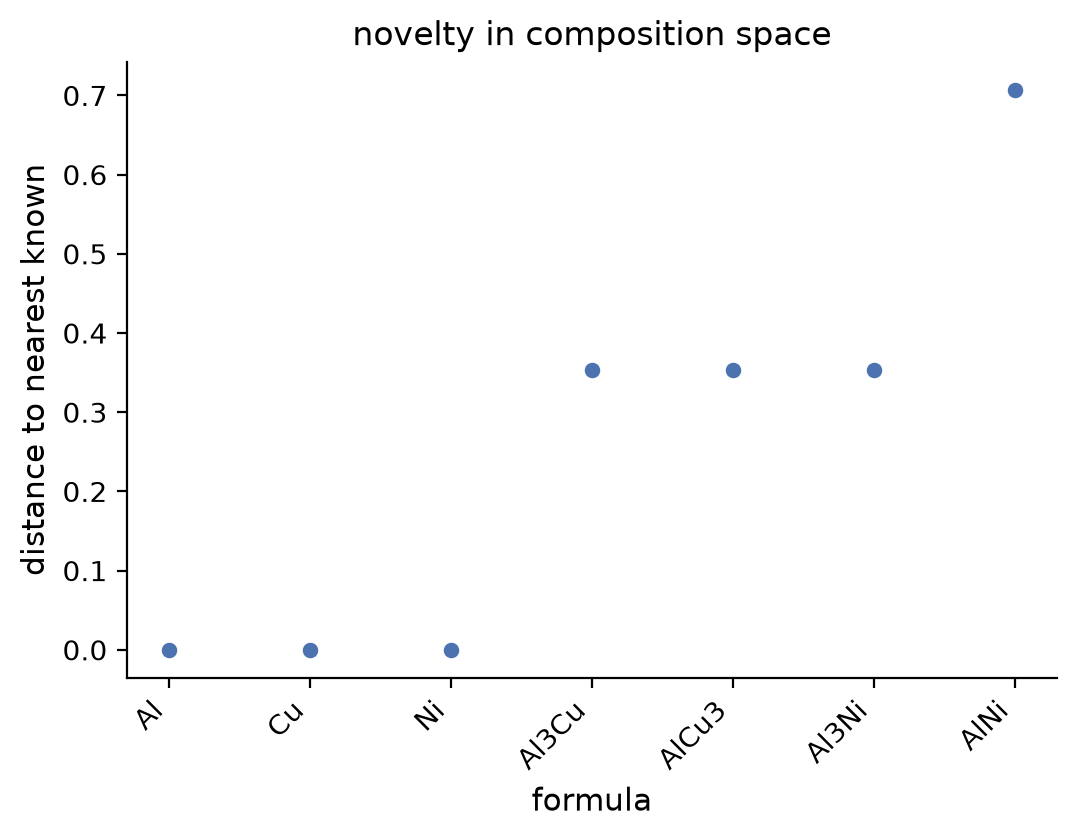

In [20]:
ax = mv.pl.scatter(md, "formula", "novelty_distance")
ax.set_ylabel("distance to nearest known")
ax.set_title("novelty in composition space")

```{warning}
Composition-space distance answers "is this chemistry new", not "is this
structure new". A novel polymorph of a known composition scores zero — which is
exactly what the three elementals do above. For structural novelty, concatenate
against the reference and run `mv.pp.dedup`.
```

## Does the bet hold?

`X` as the composition matrix is a bet, and the test that would kill it is in
the suite:

```
tests/test_pipeline.py::TestTools::test_rank_elements_groups_recovers_the_obvious_chemistry
```

It groups materials by whether they contain Al and asserts that the top ranked
element is Al. If element-level enrichment ever stops recovering chemistry a
domain expert would recognise, the design falls back to the width-zero `X` of
v0.1 — `mv.data.from_structures(..., build_X=False)` — and nothing else changes.

## Before there is a structure at all

Everything so far started from structures. The bet that `X` is the composition
matrix has a consequence worth using: a dataset needs **no structures at all**
to be a matverse object. `mv.data.from_compositions` builds one from formulas,
and everything that reads composition works on it unchanged.

In [21]:
candidates = mv.data.from_compositions(["BaTiO3", "SrTiO3", "CaTiO3", "PbTiO3"])
mv.feat.element_stats(candidates)
print(candidates)

AnnData object with n_obs × n_vars = 4 × 6
    obs: 'formula'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is'
    obsm: 'X_element_stats'
    layers: None (.X)


Anything that reads a *structure* raises, and should — there is none, and
inventing one would be inventing the answer.

That makes room for the cheapest filter in the whole funnel, and the only one
that runs before a structure exists. `mv.gen.compositions` enumerates
compositions that are **charge neutral** in some combination of their elements'
known oxidation states, with the more electronegative element taking the more
negative one. Everything else is discarded for the cost of arithmetic.

In [22]:
try:
    found = mv.gen.compositions(["Ba", "Ti", "O"], threshold=4)
    print(f"{found.n_obs} candidates from Ba-Ti-O")
    print(found.obs[["formula", "n_elements", "n_oxidation_assignments"]]
          .head(8).to_string(index=False))
    print("\nBaTiO3 among them:", "BaTiO3" in set(found.obs["formula"]))
except ImportError:
    print("needs SMACT; pip install matverse[screening]")

16 candidates from Ba-Ti-O
formula  n_elements  n_oxidation_assignments
    BaO           2                        1
   BaO2           2                        1
    TiO           2                        1
   TiO2           2                        2
  Ti2O3           2                        1
   TiO3           2                        1
   TiO4           2                        1
 BaTiO2           3                        1

BaTiO3 among them: True


```{warning}
Surviving this is **not** a prediction that the compound exists. It is a
statement that one reason for it not to has been ruled out — the filter passes
roughly a thousand compositions for every one that has ever been made. It is a
way of not wasting a calculator on CaF3, not a way of finding new materials.
```

Two details that change the answer, so both are recorded in
`uns['compositions']`:

**A composition often has more than one charge-neutral assignment**, and charge
neutrality cannot say which is meant. SMACT returns TiO₂ twice — as
Ti(+2)O(−1) and as the rutile-like Ti(+4)O(−2). `obs['oxidation_states']` lists
all of them rather than reporting whichever came first, which would have
labelled ordinary TiO₂ a peroxide.

In [23]:
try:
    ti_o = mv.gen.compositions(["Ti", "O"], threshold=4)
    print(ti_o.obs[["formula", "oxidation_states"]].to_string(index=False))
except ImportError:
    print("needs SMACT; pip install matverse[screening]")

formula    oxidation_states
    TiO            Ti+2 O-2
   TiO2 Ti+2 O-1 | Ti+4 O-2
  Ti2O3            Ti+3 O-2
   TiO3            Ti+3 O-1
   TiO4            Ti+4 O-1


**The oxidation-state table is a choice.** The default `'icsd24'` is what has
actually been observed in the ICSD; `'smact14'` is the older permissive set and
passes considerably more — 29 candidates against 16 on Ba–Ti–O. Neither is
wrong; they answer slightly different questions, and a screen that does not say
which it used is not reproducible.

## From a formula to a structure

A candidate needs a structure before anything else can touch it.
`mv.gen.from_symmetry` supplies one, by placing the atoms on Wyckoff positions
of a chosen space group and randomising the free parameters that remain.

In [24]:
try:
    candidates = mv.data.from_compositions(["BaTiO3", "SrTiO3"])
    built = mv.gen.from_symmetry(candidates, space_groups=[221, 99], seed=0)
    print(built.obs[["formula", "requested_space_group", "space_group",
                     "space_group_symbol", "symmetry_as_requested",
                     "nsites"]].to_string(index=False))
except ImportError:
    print("needs PyXtal; pip install matverse[generation]")

formula  requested_space_group  space_group space_group_symbol  symmetry_as_requested  nsites
 BaTiO3                    221          221              Pm-3m                   True       5
 BaTiO3                     99           99               P4mm                   True       5
 SrTiO3                    221          221              Pm-3m                   True       5
 SrTiO3                     99           99               P4mm                   True       5


```{warning}
**The output is a starting geometry, not a structure.** The cell volume is
estimated and the free coordinates are random, so bond lengths are only
approximately right — generated BaTiO₃ in Pm-3m comes out near **5.06 Å against
a measured 4.00**. Run `mv.calc.relax` before believing any energy and
`mv.gen.validate` before believing the structure.
```

Two columns rather than one, and the second is the one that matters.
`requested_space_group` is what PyXtal was asked for; `space_group` is what
pymatgen finds in the structure that came back.

They disagree **often**, not occasionally. Asking for 40 random space groups for
TiO₂ gave 7 structures, and 5 of them came back at *higher* symmetry than
requested — P-6 asked for, P6/mmm delivered — because with few atoms the random
free parameters land on a special position. A generator that reported only the
request would be reporting its input.

In [25]:
try:
    many = mv.gen.from_symmetry(mv.data.from_compositions(["TiO2"]),
                                per_composition=40, seed=1)
    n_built = many.n_obs
    n_failed = many.uns["from_symmetry"]["n_failed"]
    disagreed = int((~many.obs["symmetry_as_requested"]).sum())
    print(f"{n_built} built from 40 attempts, {n_failed} failed")
    print(f"{disagreed} of {n_built} came back at a different symmetry")
except ImportError:
    print("needs PyXtal; pip install matverse[generation]")

7 built from 40 attempts, 33 failed
5 of 7 came back at a different symmetry


/scratch/users/steorra/analysis/omicverse_dev/matverse/matverse/_registry.py:393: RuntimeWarning: 33 of 40 attempts produced no structure and are missing rows rather than substituted ones; see uns['from_symmetry']['errors']. First: TiO2 in group 109: Comp_CompatibilityError: Composition [1 2] not compatible with symmetry 109
  return func(*args, **kwargs)


Note the other number: **33 of 40 attempts failed outright**, because a random
space group usually cannot host a given composition at a given cell size. That
is honest rather than hidden — a failure is a missing row plus a counted reason
in `uns['from_symmetry']`, never a substituted structure — but it does mean
passing `space_groups=` explicitly is both faster and more likely to give what
you wanted.

The result is an ordinary materials object, so `mv.pp.describe`, `mv.calc.relax`
and everything else work on it unchanged. The funnel is now complete: elements →
compositions → structures → energies.

```{seealso}
[Beyond one number](beyond_one_number.ipynb) covers the results that are not a
single number per material: curves, per-atom values and measurements.
```